# Competition part

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
train = pd.read_csv('heart_disease_train.csv')
test = pd.read_csv('heart_disease_test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (216, 15)
Test shape: (54, 15)


In [3]:
train.head()

,Unnamed: 0,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,115,49,0,2,134,271,0,0,162,0,0.0,2,0,3,Absence
1,33,59,1,4,170,326,0,2,140,1,3.4,3,0,7,Presence
2,184,53,1,3,130,246,1,2,173,0,0.0,1,3,3,Absence
3,142,50,1,3,140,233,0,0,163,0,0.6,2,1,7,Presence
4,197,54,0,3,110,214,0,0,158,0,1.6,2,0,3,Absence


In [4]:
# Separate features and target
X_train = train.drop('Heart Disease', axis=1)
y_train = train['Heart Disease']

X_test = test.drop('Heart Disease', axis=1)
y_test = test['Heart Disease']

# Encode target if needed (Presence/Absence to 1/0)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['Absence' 'Presence']


## Logistic Regression

In [5]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, pred1)

print(f"Logistic Regression Accuracy: {acc1:.4f}")

Logistic Regression Accuracy: 0.9074


C:\Users\loukm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Decision Tree

In [7]:
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, pred2)

print(f"Decision Tree Accuracy: {acc2:.4f}")

Decision Tree Accuracy: 0.8148


## Random Forest

In [8]:
model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, pred3)

print(f"Random Forest Accuracy: {acc3:.4f}")

Random Forest Accuracy: 0.8519


## Super Vector Machine (SVM)

In [9]:
model4 = SVC(random_state=42)
model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)
acc4 = accuracy_score(y_test, pred4)

print(f"SVM Accuracy: {acc4:.4f}")

SVM Accuracy: 0.6852


## K-Nearest-Neighbors (KNN)

In [10]:
model5 = KNeighborsClassifier(n_neighbors=5)
model5.fit(X_train, y_train)

pred5 = model5.predict(X_test)
acc5 = accuracy_score(y_test, pred5)

print(f"KNN Accuracy: {acc5:.4f}")

KNN Accuracy: 0.6481


## Naive Bayes

In [11]:
model6 = GaussianNB()
model6.fit(X_train, y_train)

pred6 = model6.predict(X_test)
acc6 = accuracy_score(y_test, pred6)

print(f"Naive Bayes Accuracy: {acc6:.4f}")

Naive Bayes Accuracy: 0.9074


## Gradient Boosting

In [12]:
model7 = GradientBoostingClassifier(random_state=42)
model7.fit(X_train, y_train)

pred7 = model7.predict(X_test)
acc7 = accuracy_score(y_test, pred7)

print(f"Gradient Boosting Accuracy: {acc7:.4f}")

Gradient Boosting Accuracy: 0.8519


# Summary

In [13]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 
              'SVM', 'KNN', 'Naive Bayes', 'Gradient Boosting'],
    'Accuracy': [acc1, acc2, acc3, acc4, acc5, acc6, acc7]
})

results = results.sort_values('Accuracy', ascending=False)
print(results.to_string(index=False))

              Model  Accuracy
Logistic Regression  0.907407
        Naive Bayes  0.907407
      Random Forest  0.851852
  Gradient Boosting  0.851852
      Decision Tree  0.814815
                SVM  0.685185
                KNN  0.648148


# Visualisation

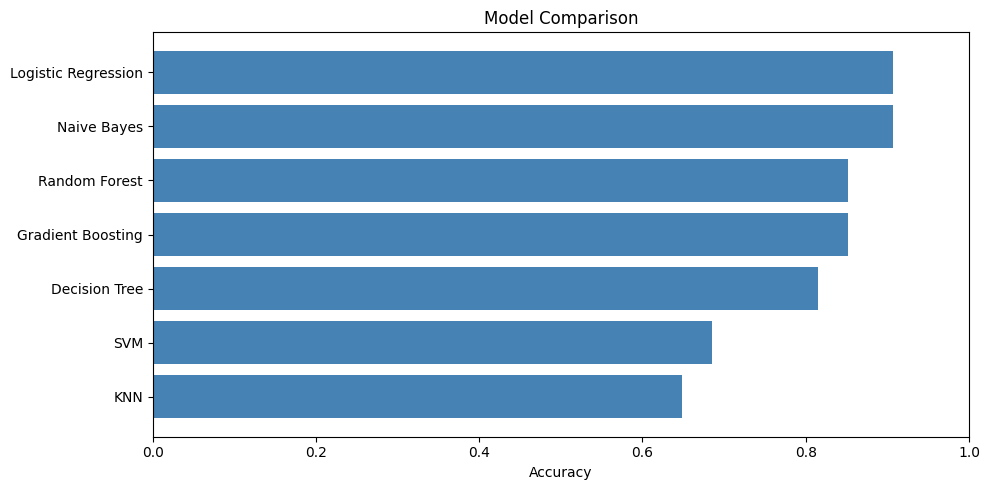

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(results['Model'], results['Accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.title('Model Comparison')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Best Model

In [15]:
best = results.iloc[0]
print(f"Best Model: {best['Model']}")
print(f"Accuracy: {best['Accuracy']:.4f}")

Best Model: Logistic Regression
Accuracy: 0.9074


#  Classification report for best model

In [17]:
# Choose the best model predictions (adjust based on results)
# Example: if Random Forest is best
print("Logistic Regression:")
print(classification_report(y_test, pred3, target_names=['Absence', 'Presence']))

Logistic Regression:
              precision    recall  f1-score   support

     Absence       0.86      0.91      0.88        33
    Presence       0.84      0.76      0.80        21

    accuracy                           0.85        54
   macro avg       0.85      0.84      0.84        54
weighted avg       0.85      0.85      0.85        54

